In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Sat Jun  4 21:33:25 2022

@author: ixn004
"""
#July 10, 2025


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

#from pyswarm import pso
from pyswarms.single.global_best import GlobalBestPSO #Date: Macrh 30,2024
from calculate_pZAP import run_bionetgen
from interpolation import spline
from ca_ODE import calcium, solve
from interpolation_exp_data import exp_idata


from data_slice import data_after_tstart
from ZAP_SYK_SSR_fit import calculate_residue
from calculate_SSR_gamma import gamma_PZAP
from calculate_SSR_zeta import zeta_PZAP    
from calculate_SSR_mixed import mixed_PZAP
import sys
      


In [6]:
data_gamma=pd.read_csv('../hCD16_Ca_expt/ca_data/gamma.dat',sep="\t", comment='#', header=None)
data_zeta=pd.read_csv('../hCD16_Ca_expt/ca_data/zeta.dat',sep="\t", comment='#', header=None)
data_mixed=pd.read_csv('../hCD16_Ca_expt/ca_data/mixed.dat',sep="\t", comment='#', header=None)

global exp_time_gamma, exp_data_gamma, exp_time_zeta, exp_data_zeta, exp_time_mixed, exp_data_mixed
#if the data has a time column:
start_time=time.time()

data_gamma=np.asarray(data_gamma) 
data_zeta=np.asarray(data_zeta)
data_mixed=np.asarray(data_mixed)

exp_time_gamma=data_gamma[:,0]
exp_data_gamma=data_gamma[:,1]

exp_time_zeta=data_zeta[:,0]
exp_data_zeta=data_zeta[:,1]

exp_time_mixed=data_mixed[:,0]
exp_data_mixed=data_mixed[:,1]

In [7]:
estimates=[-2.4449488148175647, -0.3026153422748695, 5.631798668703095, 0.44555561384747805, -1.9427485901941413, 1.3358861405639382, 3.0531451148915383, 2.9207350903093805, 908.5857924281636]

K1 = 10**estimates[0]
K2 = 10**estimates[1]

C1 = 10**estimates[2]
C2 = 10**estimates[3]
g= 10**estimates[4]

a0 = 10**estimates[5]
ZAP0 = 10**estimates[6]
SYK0 = 10**estimates[7]   

n = 3  # Number of bionetgen runs

dir_name="analysis"
print(f'kon={K1}')
print(f'koff={K2}')
print(f'C1={C1}')
print(f'C2={C2}')
print(f'g={g}')
print(f'adaptor={a0}')
print(f'ZAP0={ZAP0}')
print(f'SYK0={SYK0}')

kon=0.003589642390447348
koff=0.498178129560167
C1=428349.8988696909
C2=2.7896878686669084
g=0.011409100606736063
adaptor=21.6713587007035
ZAP0=1130.1734870634534
SYK0=833.1728132476834


In [ ]:
beta=1.0
tnew_zeta, PZAP_zeta, PSYK_zeta, N, dir_name_zeta = zeta_PZAP(n, K1, K2, a0*beta, ZAP0, SYK0, dir_name)
# tnew_mixed, PZAP_mixed, PSYK_mixed, N, dir_name_mixed = mixed_PZAP(n, K1, K2, a0, ZAP0, SYK0, dir_name)
# tnew_gamma, PZAP_gamma, PSYK_gamma, N, dir_name_gamma = gamma_PZAP(n, K1, K2, a0, ZAP0, SYK0, dir_name)


k1 = 0.003589642390447348
k2 = 0.498178129560167
A0= 2.16713587007035
ZAP0= 1130.1734870634534
SYK0= 833.1728132476834
Running bionetgen simulations in directory: zeta_runs/analysis


In [ ]:
alpha=1.0


residue_zeta,t_zeta,EXPT_zeta,Ca_zeta = calculate_residue(n, tnew_zeta, PZAP_zeta, PSYK_zeta, exp_time_zeta, exp_data_zeta, alpha*C1, C2, g, N, dir_name_zeta)
# residue_mixed,t_mixed,EXPT_mixed,Ca_mixed = calculate_residue(n, tnew_mixed, alpha*PZAP_mixed, PSYK_mixed, exp_time_mixed, exp_data_mixed, C1, C2, g, N, dir_name_mixed)
# residue_gamma,t_gamma,EXPT_gamma,Ca_gamma = calculate_residue(n, tnew_gamma, alpha*PZAP_gamma, PSYK_gamma, exp_time_gamma, exp_data_gamma, C1, C2, g, N, dir_name_gamma)

C1 = 428349.8988696909
C2 = 2.7896878686669084
g = 0.011409100606736063
ca0 in main 28905.757213062436
[28905.75721306 28891.69730124 28877.72745844 ... 26226.13135471
 26214.40465336 26202.6799258 ]


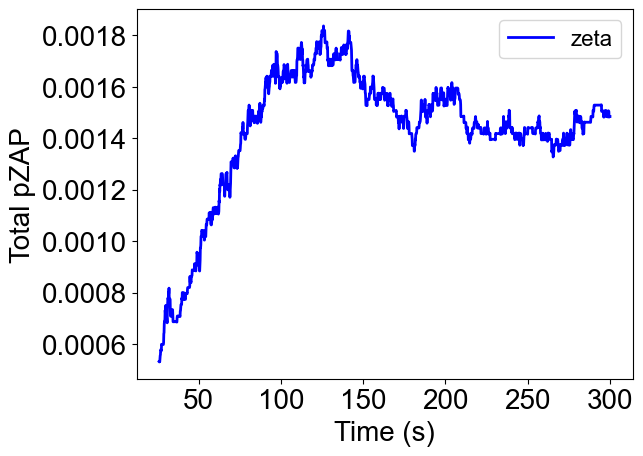

residue_total=3460291911737.069


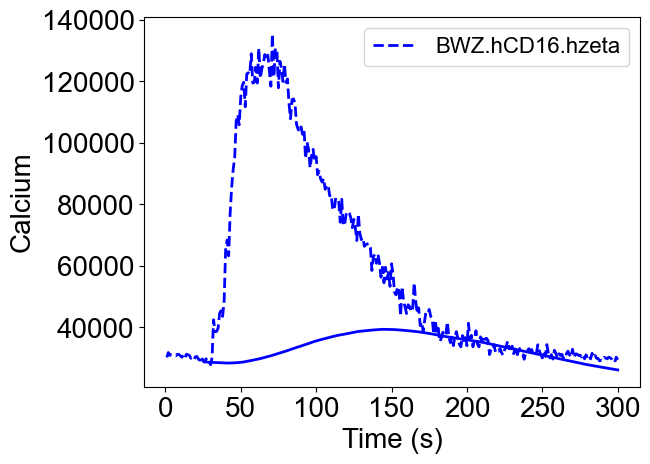

In [32]:
Vc=25.0 #pZAP molecules in the simulation box of size 25 um^3
z=602.0 #constant factor to convert from molecules/um3 to uM
    
plt.figure()
plt.plot(tnew_zeta, alpha*PZAP_zeta, label='zeta',color='blue', linewidth=2)
# plt.plot(tnew_mixed, alpha*PZAP_mixed*Vc*z, label='Hetero',color='cornflowerblue', linewidth=2)
# plt.plot(tnew_gamma, alpha*PZAP_gamma*Vc*z, label='gamma',color='orange', linewidth=2)
plt.xlabel('Time (s)', fontfamily='Arial', fontsize=20)
plt.ylabel('Total pZAP', fontfamily='Arial', fontsize=20)
plt.xticks(fontfamily='Arial', fontsize=20)
plt.yticks(fontfamily='Arial', fontsize=20)
plt.legend(prop={'family': 'Arial', 'size': 16})
plt.show()


#Experimental data
plt.plot(exp_time_zeta,exp_data_zeta,color='blue',linewidth=2,linestyle='--',label='BWZ.hCD16.hzeta')
plt.plot(t_zeta,Ca_zeta,color='blue',linewidth=2)


residue_total=residue_zeta
print(f"residue_total={residue_total}")
plt.xlabel('Time (s)', fontfamily='Arial', fontsize=20)
plt.ylabel('Calcium', fontfamily='Arial', fontsize=20)
plt.xticks(fontfamily='Arial', fontsize=20)
plt.yticks(fontfamily='Arial', fontsize=20)
plt.legend(prop={'family': 'Arial', 'size': 16})   
plt.show()

